In [47]:
# 1. Bibliothèques standard Python
import os
import numpy as np

# 2. Bibliothèques tierces
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 3. Modules sklearn
##librairie pour modèle de régression linéaire
from sklearn.linear_model import LinearRegression
## Librairie pour l'entrainement et test du modèle
from sklearn.model_selection import train_test_split
## librairie pour RMSE et MAPE ( écart entre les vraies valeurs de test et celles prédite pas le modèle)
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
## Normaliser l'amplitude en utilisant minmaxscaler qui force les variables entre 0 et 1
from sklearn.preprocessing import MinMaxScaler
## Calcul de a précission
from sklearn.metrics import accuracy_score

In [12]:
# import via url RAW de github
df = pd.read_csv('https://raw.githubusercontent.com/OpenClassrooms-Student-Center/8063076-Initiez-vous-au-Machine-Learning/refs/heads/master/data/advertising.csv')
# Explorons rapidement les données avec
df.head()


,tv,radio,journaux,ventes
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [13]:
df.describe()

,tv,radio,journaux,ventes
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,14.022500
std,85.854236,14.846809,21.778621,5.217457
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,10.375000
50%,149.750000,22.900000,25.750000,12.900000
75%,218.825000,36.525000,45.100000,17.400000
max,296.400000,49.600000,114.000000,27.000000


<Axes: xlabel='tv', ylabel='ventes'>

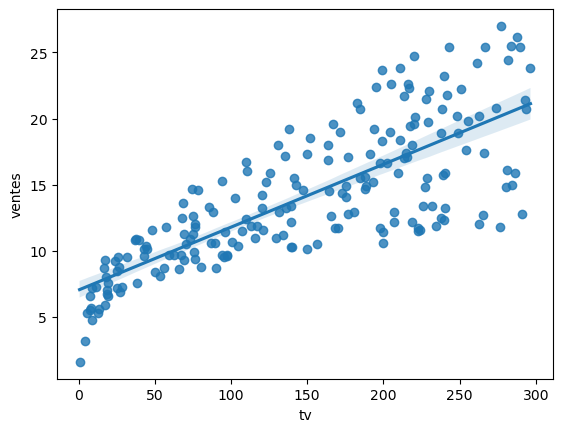

In [14]:
#La fonction  regplot()  permet non seulement d'afficher le nuage de points des variables 
# tv  ,  radio  et  journaux  en fonction des ventes, 
#mais aussi de tracer la ligne de régression
sns.regplot(data=df, x="tv", y="ventes")

In [15]:
# coef de corrélation pour confirmer 1 = très corrélé
df.corr()

,tv,radio,journaux,ventes
tv,1.000000,0.054809,0.056648,0.782224
radio,0.054809,1.000000,0.354104,0.576223
journaux,0.056648,0.354104,1.000000,0.228299
ventes,0.782224,0.576223,0.228299,1.000000


In [17]:
# modèle de régression linéaire de scikit-learn
reg = LinearRegression()



In [21]:
# Scinder le dataset en une partie train et une partie test
X = df[['tv','radio','journaux']]
y = df.ventes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [22]:
#On entraîne le modèle
reg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [23]:
#Estimation de la performance
y_pred_test = reg.predict(X_test)

In [29]:
# écart entre les vraies valeurs de test et celles prédite pas le modèle
# score petit = meilleur modèle --> RMSE pas contraint | MAPE compris entre 0 et 1
print(f"RMSE: {mean_squared_error(y_test, y_pred_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_pred_test)}")

RMSE: 3.1740973539761055
MAPE: 0.1519884660283123


______________
Amélioration du modèle: 1_Ajouter un terme quadratique
______________

In [30]:
# nouvelle variable tv2 = tv²
df['tv2'] = df.tv**2

In [32]:
# création d'un scaler ( instancier)
scaler = MinMaxScaler()

In [33]:
#calcul du min et max
scaler.fit(df)

,feature_range,"(0, ...)"
,copy,True
,clip,False


In [34]:
 # Transformer les données
data_array = scaler.transform(df)
# Le résultat est un array

In [35]:
# Recréation d'un dataframe
df = pd.DataFrame(data_array, columns = ['tv','radio','journaux','ventes','tv2'])

In [36]:
df.describe().loc[['min','max']]

,tv,radio,journaux,ventes,tv2
min,0.0,0.0,0.0,0.0,0.0
max,1.0,1.0,1.0,1.0,1.0


In [38]:
# régression plynomiale avec la présence de tv2.
# Train
X = df[['tv','radio','journaux', 'tv2']]
y = df.ventes

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

reg.fit(X_train, y_train)
y_hat_test = reg.predict(X_test)

print(f"Coefficients: {reg.coef_}")
print(f"RMSE: {mean_squared_error(y_test, y_hat_test)}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, y_hat_test)}")

Coefficients: [ 0.88007136  0.37464292  0.02197664 -0.36578279]
RMSE: 0.003686398861606466
MAPE: 0.16200182799935675


_________
Résolvez un problème de classification avec la régression logistique

In [41]:
from sklearn.datasets import load_breast_cancer
X, y = load_breast_cancer(return_X_y=True)

from sklearn.linear_model import LogisticRegression
clf = LogisticRegression(random_state=808).fit(X, y)

/home/camille_sc/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [42]:
clf.predict([X[8, :]])

array([0])

In [43]:
clf.predict([X[13, :]])

array([1])

In [45]:
#probabilité de 0 ou 1 où 0 bénin et 1 malin
clf.predict_proba([X[8, :]])


array([[0.69477411, 0.30522589]])

<Axes: ylabel='Count'>

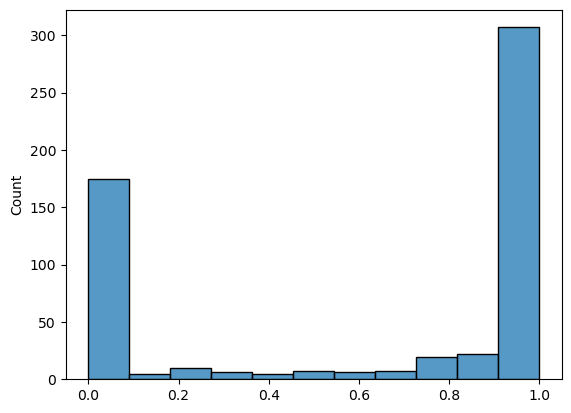

In [46]:
#'analyser les performances d'un modèle de classification
#consiste à tracer l'histogramme des probabilités des prédictions.
y_hat_proba = clf.predict_proba(X)[:,1]
sns.histplot(y_hat_proba)

In [48]:
#prédiction du modèle
y_pred = clf.predict(X)

In [49]:
# exactitude des prédiction
accuracy_score(y, y_pred)

0.945518453427065

In [50]:
#modèle biaisé? utilisation matrice de confusion
from sklearn.metrics import confusion_matrix
confusion_matrix(y, y_pred)

array([[193,  19],
       [ 12, 345]])

___________________
Partitionnez les données avec k-means

In [52]:
from sklearn.datasets import make_blobs
centers = [[2, 2], [-2, -2], [2, -2]]
X, labels_true = make_blobs(
                      n_samples=3000, 
                      centers=centers, 
                      cluster_std=0.7)

In [53]:
from sklearn.cluster import KMeans
k_means = KMeans( n_clusters=3, random_state = 808)
k_means.fit(X)
print(k_means.cluster_centers_)

[[-1.99334311 -1.98707432]
 [ 2.01549229  1.99490004]
 [ 2.01896593 -1.97996439]]


In [54]:
from sklearn.metrics import silhouette_score
k_means_labels = k_means.predict(X)
print("silhouette_score: ", silhouette_score(X,k_means_labels ))

silhouette_score:  0.6783521996704084


In [55]:
from palmerpenguins import load_penguins
data = load_penguins()

In [56]:
data.head()


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


In [57]:
reg = LinearRegression()
X = data['bill_length_mm'].values.reshape(-1, 1)
y = data['body_mass_g']
reg.fit(X, y)

ValueError: Input X contains NaN.
LinearRegression does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values